In [3]:
import os
import glob
import freesound
import random
import pandas as pd
import json
import IPython.display as ipd
import essentia
import essentia.standard as es
import numpy as np
import matplotlib.pyplot as plt

from datetime import datetime

[   INFO   ] MusicExtractorSVM: no classifier models were configured by default


In [4]:
from helpers import (
    query_freesound,
    retrieve_sound_preview,
    sounds_to_dataframe,
    delete_dataset_with_gc,
    detect_onsets,
    plot_waveform_with_onsets
)

### Query examples from Freesound

In [5]:
FREESOUND_STORE_METADATA_FIELDS = ['id', 'name', 'username', 'previews', 'license', 'tags']

In [6]:
FREESOUND_API_KEY = os.getenv('FREESOUND_API_KEY')

client = freesound.FreesoundClient()
client.set_token(FREESOUND_API_KEY)

In [10]:
AUDIO_DIR = "../data/audio/"
META_DIR = "../data/meta/"

os.makedirs(AUDIO_DIR, exist_ok=True)
os.makedirs(META_DIR, exist_ok=True)

In [40]:
# Queries for THIS RUN
freesound_queries = [
    {
        "query": "dog bark",
        "filter": None,
        "num_results": 20,
    },
]

In [41]:
# ACTUAL QUERY SCRIPT
# Timestamp to uniquely identify this run
timestamp = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
meta_csv_path = os.path.join(META_DIR, f"dataset_{timestamp}.csv")
meta_json_path = os.path.join(META_DIR, f"dataset_{timestamp}.json")

# --------------------------------------------------
# Run queries
# --------------------------------------------------
sounds = []
for q in freesound_queries:
    sounds.extend(
        query_freesound(
            query=q["query"],
            filter=q["filter"],
            client=client,
            fs_store_metadata_fields=FREESOUND_STORE_METADATA_FIELDS,
            num_results=q["num_results"],
        )
    )

print(f"Retrieved {len(sounds)} sound metadata objects")

# --------------------------------------------------
# Download previews (idempotent)
# --------------------------------------------------
for i, sound in enumerate(sounds, 1):
    print(f"[{i}/{len(sounds)}] Downloading sound ID {sound.id}")
    retrieve_sound_preview(client, sound, AUDIO_DIR)

# --------------------------------------------------
# Save metadata for THIS RUN ONLY
# --------------------------------------------------
df = sounds_to_dataframe(sounds, AUDIO_DIR)
df.to_csv(meta_csv_path, index=False)
print(f"Saved metadata CSV: {meta_csv_path}")

# --------------------------------------------------
# Save query log
# --------------------------------------------------
query_log = {
    "timestamp": timestamp,
    "num_sounds": len(sounds),
    "queries": freesound_queries,
}

with open(meta_json_path, "w") as f:
    json.dump(query_log, f, indent=2)

print(f"Saved query log JSON: {meta_json_path}")

FreesoundException: <FreesoundException: code=401, detail="Unauthorized">

In [42]:
!ls ../data/meta

dataset_2026-01-18_19-30-57.csv   dataset_2026-03-18_18-36-36.csv
dataset_2026-01-18_19-30-57.json  dataset_2026-03-18_18-36-36.json
dataset_2026-03-18_18-32-10.csv   dataset_2026-04-30_17-46-52.csv
dataset_2026-03-18_18-32-10.json  dataset_2026-04-30_17-46-52.json
dataset_2026-03-18_18-35-35.csv   dataset_2026-05-01_13-19-37.csv
dataset_2026-03-18_18-35-35.json  dataset_2026-05-01_13-19-37.json


In [64]:
!cat ../data/meta/dataset_2026-04-30_17-46-52.json

{
  "timestamp": "2026-04-30_17-46-52",
  "num_sounds": 20,
  "queries": [
    {
      "query": "chopping wood",
      "filter": null,
      "num_results": 20
    }
  ]
}

In [36]:
delete_dataset_with_gc(META_DIR + "dataset_2026-01-18_13-58-47.csv", META_DIR, AUDIO_DIR, dry_run=False)

Deleted metadata file: /workspace/data/meta/dataset_2026-01-18_13-58-47.csv
Deleted query file: /workspace/data/meta/dataset_2026-01-18_13-58-47.json
Deleted audio: /workspace/data/audio/254192_1810340-hq.ogg
Deleted audio: /workspace/data/audio/749351_16213215-hq.ogg
Deleted audio: /workspace/data/audio/274810_2341415-hq.ogg
Deleted audio: /workspace/data/audio/542337_12117661-hq.ogg
Deleted audio: /workspace/data/audio/160092_2888453-hq.ogg
Deleted audio: /workspace/data/audio/418108_6078577-hq.ogg
Deleted audio: /workspace/data/audio/273968_2328840-hq.ogg
Deleted audio: /workspace/data/audio/536631_9771749-hq.ogg
Deleted audio: /workspace/data/audio/743462_1648170-hq.ogg
Deleted audio: /workspace/data/audio/553171_11512256-hq.ogg
Deleted audio: /workspace/data/audio/664130_14556113-hq.ogg
Deleted audio: /workspace/data/audio/655915_11016162-hq.ogg
Deleted audio: /workspace/data/audio/117198_117285-hq.ogg
Deleted audio: /workspace/data/audio/236189_180659-hq.ogg
Deleted audio: /works

### Show downloaded audio

In [66]:
!ls -lt ../data/audio | head -20

total 16344
-rw-r--r-- 1 root root 118672 May  1 13:19 560237_12522432-hq.ogg
-rw-r--r-- 1 root root 143805 May  1 13:19 16744_26950-hq.ogg
-rw-r--r-- 1 root root 204555 May  1 13:19 832868_18115820-hq.ogg
-rw-r--r-- 1 root root 146336 May  1 13:19 389672_7158173-hq.ogg
-rw-r--r-- 1 root root 138272 May  1 13:19 389464_6060491-hq.ogg
-rw-r--r-- 1 root root 406622 May  1 13:19 382585_313780-hq.ogg
-rw-r--r-- 1 root root 104316 May  1 13:19 119114_1550701-hq.ogg
-rw-r--r-- 1 root root  46650 May  1 13:19 827443_17908330-hq.ogg
-rw-r--r-- 1 root root 131921 May  1 13:19 384411_5407590-hq.ogg
-rw-r--r-- 1 root root  83310 May  1 13:19 816996_17552599-hq.ogg
-rw-r--r-- 1 root root 168144 May  1 13:19 406230_6068748-hq.ogg
-rw-r--r-- 1 root root 190055 May  1 13:19 347407_6325453-hq.ogg
-rw-r--r-- 1 root root 119743 May  1 13:19 16743_26950-hq.ogg
-rw-r--r-- 1 root root 165502 May  1 13:19 131469_2337088-hq.ogg
-rw-r--r-- 1 root root  42759 May  1 13:19 34992_268901-hq.ogg
-rw-r--r-- 1 root 

In [73]:
# select a file manually
filename = "766242_15773983-hq.ogg"
filename = AUDIO_DIR + filename
filename

'../data/audio/766242_15773983-hq.ogg'

In [68]:
# select a file randomly
filename = random.choice(os.listdir(AUDIO_DIR))
filename = AUDIO_DIR + filename
filename

'../data/audio/389672_7158173-hq.ogg'

/usr/local/lib/python3.10/dist-packages/matplotlib/axes/_axes.py:8283: RuntimeWarning: divide by zero encountered in log10
  Z = 10. * np.log10(spec)


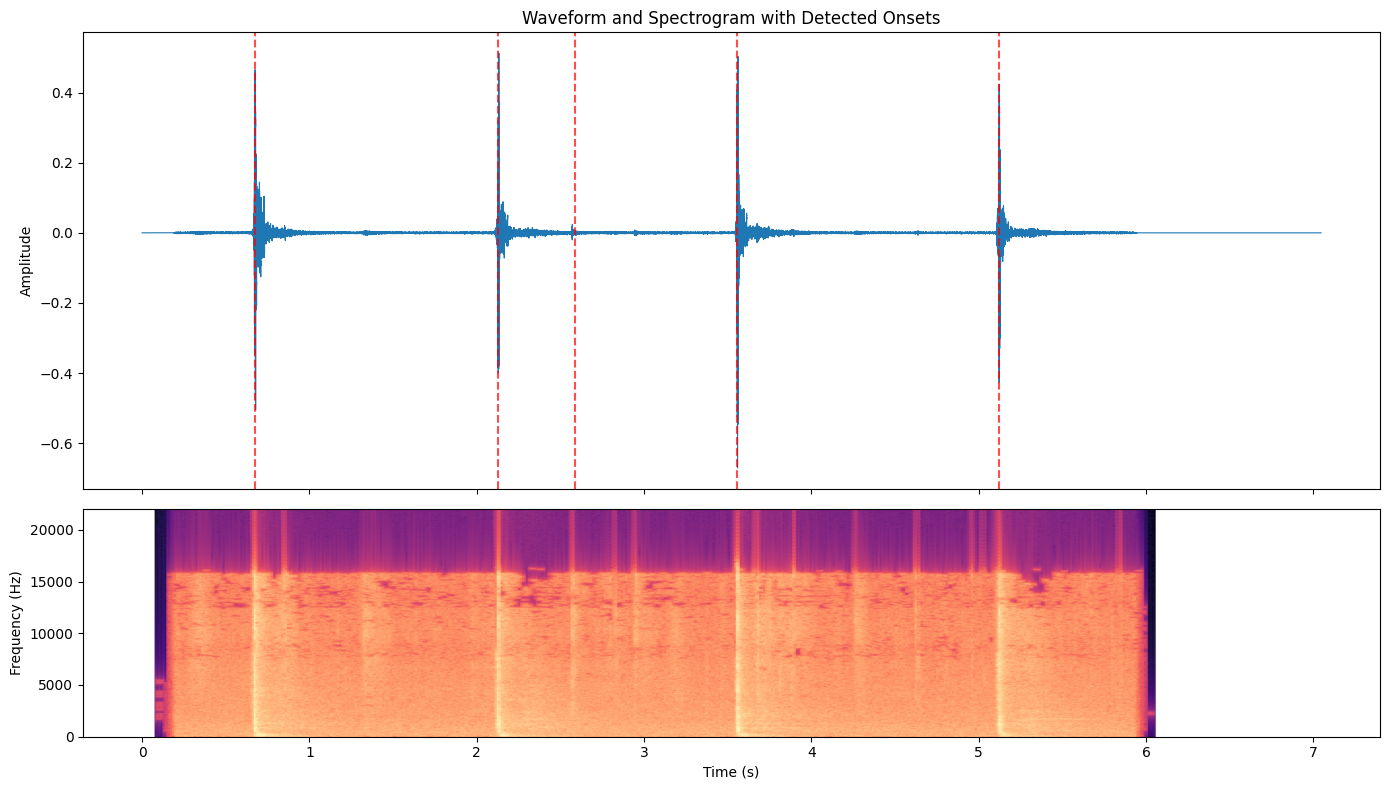

In [74]:
start_time = None
end_time = None
sr = 44100

audio, onset_times = detect_onsets(filename)

plot_waveform_with_onsets(
    audio,
    onset_times,
    sample_rate=sr,
    start_time=start_time,
    end_time=end_time
)

# Audio playback
start_sample = int(start_time * sr) if start_time else 0
end_sample = int(end_time * sr) if end_time else len(audio)-1

ipd.Audio(audio[start_sample:end_sample], rate=sr)

In [22]:
import os
import glob
import json
import pandas as pd
from IPython.display import display, Audio

def _build_query_map(meta_dir):
    """Internal helper to map query strings to sets of unique Freesound IDs."""
    query_to_ids = {}
    global_unique_ids = set() # Tracks absolute unique sounds across ALL datasets
    
    for csv_path in glob.glob(os.path.join(meta_dir, "*.csv")):
        json_path = csv_path.rsplit(".", 1)[0] + ".json"
        
        # Fallback to filename if JSON parsing fails
        query_str = os.path.basename(csv_path) 
        
        if os.path.exists(json_path):
            try:
                with open(json_path, 'r') as f:
                    data = json.load(f)
                    
                    # Parse the new list structure: {"queries": [{"query": "dog bark"}, ...]}
                    if "queries" in data and isinstance(data["queries"], list):
                        # Extract all query strings and join them with ' + '
                        q_list = [q.get("query", "") for q in data["queries"]]
                        # Filter out empty strings just in case
                        query_str = " + ".join(filter(None, q_list)) 
            except Exception as e:
                pass
                
        df = pd.read_csv(csv_path)
        if "sound_id" in df.columns:
            if query_str not in query_to_ids:
                query_to_ids[query_str] = set()
            
            # Add to the specific query bucket
            unique_in_csv = df["sound_id"].unique()
            query_to_ids[query_str].update(unique_in_csv)
            
            # Add to the global master list
            global_unique_ids.update(unique_in_csv)
            
    return query_to_ids, global_unique_ids

# ---------------------------------------------------------
def summarize_queries(meta_dir):
    """Prints a table of all queries and the number of unique sounds for each."""
    query_map, global_unique = _build_query_map(meta_dir)
    
    # Widened the column to fit "dog bark + repeated hits"
    print(f"{'Query String':<45} | {'Unique Sounds'}")
    print("-" * 65)
    
    for query, ids in sorted(query_map.items()):
        print(f"{query:<45} | {len(ids)}")
        
    print("-" * 65)
    # This should now exactly match your `ls | wc -l` count!
    print(f"{'TOTAL ABSOLUTE UNIQUE SOUNDS':<45} | {len(global_unique)}")

# ---------------------------------------------------------
# 2. Get IDs for a Specific Query
# ---------------------------------------------------------
def print_ids_for_query(meta_dir, target_query):
    """Given a query string, prints all associated Freesound IDs."""
    query_map, _ = _build_query_map(meta_dir) # Ignore global set here
    
    if target_query in query_map:
        ids = list(query_map[target_query])
        print(f"Found {len(ids)} unique sounds for query: '{target_query}'\n")
        print(ids)
        return ids
    else:
        print(f"Query '{target_query}' not found. Check exact spelling in the summary table.")
        return []

# ---------------------------------------------------------
# 3. Inspect, Plot, and Play a Specific Sound ID
# ---------------------------------------------------------
def inspect_sound(meta_dir, sound_id):
    """
    Looks up a Freesound ID, prints metadata, plots the waveform/spectrogram 
    with onsets, and displays a playable audio widget.
    """
    for csv_path in glob.glob(os.path.join(meta_dir, "*.csv")):
        df = pd.read_csv(csv_path)
        
        if "sound_id" in df.columns:
            match = df[df["sound_id"] == sound_id]
            
            if not match.empty:
                row = match.iloc[0]
                local_path = row["local_path"]
                
                print(f"--- Sound ID: {sound_id} ---")
                print(f"Name: {row.get('name', 'N/A')}")
                print(f"Tags: {row.get('tags', 'N/A')}")
                print(f"Path: {local_path}\n")
                
                if not os.path.exists(local_path):
                    print("Error: Audio file not found on disk. Run ensure_datasets_audio().")
                    return
                
                # Run onset detection
                audio, onsets = detect_onsets(local_path)
                print(f"Detected {len(onsets)} onsets via complex ODF.")
                
                # Plot
                plot_waveform_with_onsets(audio, onsets)
                
                # Display playback widget
                display(Audio(local_path))
                return
                
    print(f"Sound ID {sound_id} not found in any metadata CSV.")

In [43]:
summarize_queries(META_DIR)

Query String                                  | Unique Sounds
-----------------------------------------------------------------
chopping wood                                 | 20
fireworks                                     | 20
ping pong                                     | 20
popcorn                                       | 20
running water                                 | 20
-----------------------------------------------------------------
TOTAL ABSOLUTE UNIQUE SOUNDS                  | 100


In [45]:
ids = print_ids_for_query("data/meta", "chopping wood")

Query 'chopping wood' not found. Check exact spelling in the summary table.


In [26]:
from helpers import ensure_datasets_audio
ensure_datasets_audio(META_DIR,client,verbose=False)

---

### Analyze repetitiveness

In [82]:
import sklearn
import essentia.standard as es
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from sklearn.metrics import pairwise_distances

def analyze_repetitiveness(audio_path, sr=44100, window_ms=150, lat_threshold=0.08, eps=0.15):
    """
    Analyzes an audio file for repetitive percussive events.
    
    1. Detects onsets.
    2. Calculates LogAttackTime and MFCCs for the 150ms window after each onset.
    3. Filters out sounds with slow attacks (non-percussive).
    4. Clusters the remaining MFCC signatures to find repetitions.
    """
    print(f"--- Analyzing: {audio_path.split('/')[-1]} ---")
    
    # 1. load audio and detect onsets
    audio = es.MonoLoader(filename=audio_path, sampleRate=sr)()
    od_method = es.OnsetDetection(method='hfc')
    w = es.Windowing(type='hann')
    fft = es.FFT()
    c2p = es.CartesianToPolar()
    
    pool = essentia.Pool()
    for frame in es.FrameGenerator(audio, frameSize=1024, hopSize=512):
        mag, phase = c2p(fft(w(frame)))
        pool.add('odf.method', od_method(mag, phase))

    onsets = es.Onsets()(essentia.array([pool['odf.method']]), [1])
    print(f"Total raw onsets detected: {len(onsets)}")
    
    if len(onsets) == 0:
        return None
    
    # 2. extract Features per onset
    window_samples = int((window_ms / 1000.0) * sr)
    
    # Essentia extractors
    envelope = es.Envelope()
    log_attack = es.LogAttackTime()
    spectrum = es.Spectrum()
    mfcc = es.MFCC(inputSize=513)
    
    features = []
    last_onset_time = -1.0

    min_ioi = 0.25  # adjustable param
    
    for onset in onsets:
        # if this onset is too close the last valid one, skip it
        # (avoids picking up echoes of the sound events)
        if (onset - last_onset_time) < min_ioi:
            continue
        
        start_idx = int(onset * sr)
        end_idx = min(start_idx + window_samples, len(audio))
        segment = audio[start_idx:end_idx]
        
        # skip if too close to the end of the file
        if len(segment) < 1024:
            continue


        # Peak amplitude divided by RMS (average) amplitude
        peak_amp = np.max(np.abs(segment))
        rms_amp = np.sqrt(np.mean(segment**2)) + 1e-9 
        crest_factor = peak_amp / rms_amp

        # skip sounds that are not "peaky"
        if crest_factor < 5.0:  # adjustable parameter
            continue
            
        # LogAttackTime algorithm expects the envelope of the signal
        env = envelope(segment)
        try:
            # returns: (logAttackTime, attackStart, attackStop)
            lat = log_attack(env)[0] 
        except:
            lat = 1.0 # default high value if it fails
            
        # sound event similarity: MFCC;
        # - this method of measuring sound event similarity could be considered
        #   a variable parameter; this block would need to be rewritten in a more
        #   more modular fashion
        segment_mfccs = []
        for frame in es.FrameGenerator(segment, frameSize=1024, hopSize=512, startFromZero=True):
            _, mfcc_coeffs = mfcc(spectrum(w(frame)))
            
            # exclude the 0th coefficient (energy) so we cluster by timbre, not volume
            segment_mfccs.append(mfcc_coeffs[1:]) 
            
        mean_mfcc = np.mean(segment_mfccs, axis=0)

        last_onset_time = onset
        
        features.append({
            'time': onset,
            'lat': lat,
            'crest': crest_factor,
            'mfcc': mean_mfcc
        })
        
    df = pd.DataFrame(features)
    
    # 3. filter by Log Attack Time
    # - keep only sharp, fast attacks
    percussive_df = df[df['lat'] < lat_threshold].copy()
    print(f"Onsets passing LAT filter (< {lat_threshold}s): {len(percussive_df)}")
    
    if len(percussive_df) < 2:
        print("Not enough percussive events to cluster.\n")
        return None
        
    # 4. clustering (pairwise similarity)
    # - convert list of arrays to 2D numpy array
    X_mfcc = np.vstack(percussive_df['mfcc'].values)
    print("Percussive onset MFCCs shape", X_mfcc.shape)
    
    # compute cosine distance (great for spectral features)
    dist_matrix = pairwise_distances(X_mfcc, metric='cosine')

    print("Dist matrix shape:", dist_matrix.shape)
    
    # DBSCAN: groups events that are similar. eps is the distance threshold.
    clusterer = DBSCAN(eps=eps, min_samples=3, metric='precomputed')
    percussive_df['cluster'] = clusterer.fit_predict(dist_matrix)
    
    # count repetitions (excluding noise, which DBSCAN labels as -1)
    clusters = percussive_df[percussive_df['cluster'] != -1]
    
    if not clusters.empty:
        largest_cluster = clusters['cluster'].value_counts().idxmax()
        rep_count = len(clusters[clusters['cluster'] == largest_cluster])
        print(f"--> Found repeating event! Repetitions count: {rep_count}\n")
    else:
        print("--> No repeating clusters found.\n")
        
    return percussive_df

# --- test on "nice" samples, positive and negative ---
wood_file = "../data/audio/766242_15773983-hq.ogg"  
water_file = "../data/audio/384411_5407590-hq.ogg" 

print("TEST 1: CHOPPING WOOD")
df_wood = analyze_repetitiveness(wood_file)

print("TEST 2: RUNNING WATER")
df_water = analyze_repetitiveness(water_file)

TEST 1: CHOPPING WOOD
--- Analyzing: 766242_15773983-hq.ogg ---
Total raw onsets detected: 6
Onsets passing LAT filter (< 0.08s): 4
Percussive onset MFCCs shape (4, 12)
Dist matrix shape: (4, 4)
--> Found repeating event! Repetitions count: 4

TEST 2: RUNNING WATER
--- Analyzing: 384411_5407590-hq.ogg ---
Total raw onsets detected: 29
Onsets passing LAT filter (< 0.08s): 4
Percussive onset MFCCs shape (4, 12)
Dist matrix shape: (4, 4)
--> No repeating clusters found.



In [80]:
df_wood.iloc[1]

time                                                2.124626
lat                                                -2.401401
crest                                              12.721688
mfcc       [102.17635, 8.997907, 13.609073, 13.488162, 23...
cluster                                                    0
Name: 1, dtype: object

In [75]:
print(f"Log Attack Time for this wood chop: {df_wood['lat'].iloc[0]}")

Log Attack Time for this wood chop: -2.173146963119507


In [40]:
!ls -lt ../data/audio

total 16344
-rw-r--r-- 1 root root 118672 May  1 13:19 560237_12522432-hq.ogg
-rw-r--r-- 1 root root 143805 May  1 13:19 16744_26950-hq.ogg
-rw-r--r-- 1 root root 204555 May  1 13:19 832868_18115820-hq.ogg
-rw-r--r-- 1 root root 146336 May  1 13:19 389672_7158173-hq.ogg
-rw-r--r-- 1 root root 138272 May  1 13:19 389464_6060491-hq.ogg
-rw-r--r-- 1 root root 406622 May  1 13:19 382585_313780-hq.ogg
-rw-r--r-- 1 root root 104316 May  1 13:19 119114_1550701-hq.ogg
-rw-r--r-- 1 root root  46650 May  1 13:19 827443_17908330-hq.ogg
-rw-r--r-- 1 root root 131921 May  1 13:19 384411_5407590-hq.ogg
-rw-r--r-- 1 root root  83310 May  1 13:19 816996_17552599-hq.ogg
-rw-r--r-- 1 root root 168144 May  1 13:19 406230_6068748-hq.ogg
-rw-r--r-- 1 root root 190055 May  1 13:19 347407_6325453-hq.ogg
-rw-r--r-- 1 root root 119743 May  1 13:19 16743_26950-hq.ogg
-rw-r--r-- 1 root root 165502 May  1 13:19 131469_2337088-hq.ogg
-rw-r--r-- 1 root root  42759 May  1 13:19 34992_268901-hq.ogg
-rw-r--r-- 1 root 